In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold
from sklearn.datasets import load_wine
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [2]:
def resultados_a_df(nombres, datos):
    """Arma un DataFrame comparativo (mínimo, máximo, media y varianza) a partir
    de los resultados de evaluar_kfold para uno o más modelos/ensambles."""

    filas = []
    for nombre, resultados in zip(nombres, datos):
        aciertos = np.array(resultados) * 100
        filas.append({
            'Modelo': nombre,
            'Particiones': len(resultados),
            'Mínimo (%)': aciertos.min(),
            'Máximo (%)': aciertos.max(),
            'Media (%)': aciertos.mean(),
            'Varianza': np.var(resultados),
        })

    df = pd.DataFrame(filas).set_index('Modelo')
    df = df.sort_values('Media (%)', ascending=False)

    return (
        df.style
        .format({
            'Mínimo (%)': '{:.2f}',
            'Máximo (%)': '{:.2f}',
            'Media (%)': '{:.2f}',
            'Varianza': '{:.6f}',
        })
        .highlight_max(subset=['Media (%)'], color='#c6f6d5')
        .highlight_min(subset=['Varianza'], color='#bee3f8')
    )

In [3]:
def evaluar_kfold(k, modelo):

    kf = KFold(n_splits=k, shuffle=True, random_state=2077)

    resultados = []

    for train, test in kf.split(X):

        X_train = X[train]
        y_train = y[train]

        X_test = X[test]
        y_test = y[test]

    
        modelo.fit(X_train, y_train)

        aciertos = modelo.score(X_test, y_test)

        resultados.append(aciertos)

    return resultados

In [4]:
def graficar(nombres, resultados, titulo = 'Aciertos por modelo en KFold', xlabel = 'Modelos'):

    plt.figure(figsize=(10, 6))

    for i in range(len(nombres)):
        aciertos = np.array(resultados[i]) * 100
        x = np.full(len(aciertos), i)

        plt.scatter(x, aciertos)

    plt.xticks(range(len(nombres)), nombres)
    plt.xlabel(xlabel)
    plt.ylabel('Porcentaje de aciertos')
        
    plt.title(titulo)
    plt.grid(axis='y')

    plt.show()

## Ejercicio 1

La biblioteca dispone de la función `train_test_split`, que permite generar una partición de entrenamiento y prueba, y `KFold`, que genera varias particiones de validación cruzada.

Estudie el uso de estas funciones y utilícelas para generar particiones a partir del conjunto de datos **Digits**, que en Scikit-learn puede cargarse usando la función `load_digits` del módulo `datasets`.

Mediante `MLPClassifier` construya un perceptrón multicapa adecuado para este conjunto de datos y analice su desempeño considerando:

- 1 única partición de datos generada mediante `train_test_split`,
- 5 particiones generadas mediante `KFold`,
- 10 particiones generadas mediante `KFold`.

Para el análisis tenga en cuenta la media y la varianza de la tasa de acierto obtenida en cada partición.

,Método de evaluación,Train,Test,Total,Aciertos (%)
Modelo,,,,,
Perceptrón multicapa,Partición 20% (train_test_split),1437,360,1797,95.0


,Particiones,Mínimo (%),Máximo (%),Media (%),Varianza
Modelo,,,,,
KFold = 10,10,91.06,98.33,95.05,0.000407
KFold = 5,5,93.59,96.94,94.77,0.000139


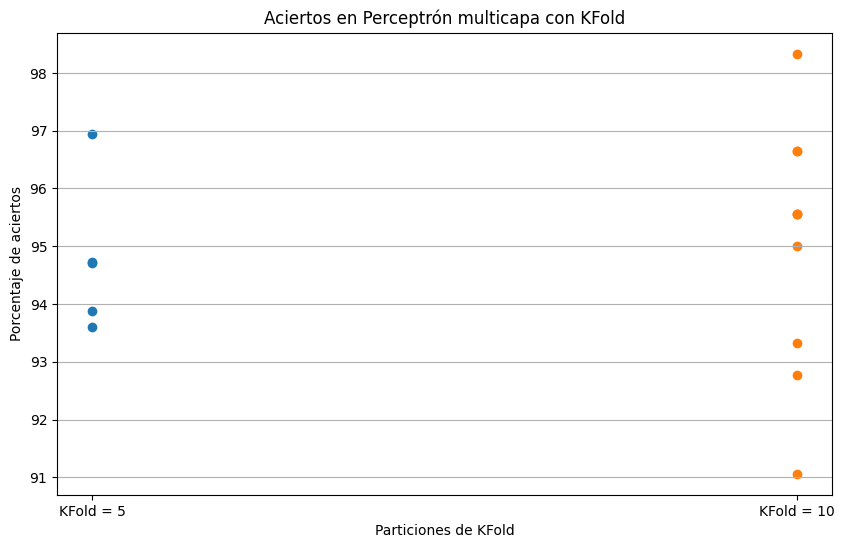

In [5]:
digits = load_digits()

X = digits.data
y = digits.target

# Partición 80/20 con train_test_split
modelo = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=2077)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2077)

modelo.fit(X_train, y_train)
aciertos = modelo.score(X_test, y_test) * 100

resumen_split = pd.DataFrame([{
    'Modelo': 'Perceptrón multicapa',
    'Método de evaluación': 'Partición 20% (train_test_split)',
    'Train': X_train.shape[0],
    'Test': X_test.shape[0],
    'Total': X_train.shape[0] + X_test.shape[0],
    'Aciertos (%)': round(aciertos, 2),
}]).set_index('Modelo')

display(resumen_split)

# Particiones con KFold (5 y 10)
ks = [5, 10]

nombre = 'Perceptrón multicapa'

titulo = 'Aciertos en Perceptrón multicapa con KFold'

xlabel = 'Particiones de KFold'

etiquetas = ['KFold = 5', 'KFold = 10']

modelos = [MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=2077), 
           MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=2077)]

datos = []
for i in range(len(ks)):
    resultados = evaluar_kfold(ks[i], modelos[i])
    datos.append(resultados)

tabla_ex1_kfold = resultados_a_df(etiquetas, datos)
display(tabla_ex1_kfold)

graficar(etiquetas, datos, titulo, xlabel)

## Análisis de resultados — Ejercicio 1

Se evaluó el desempeño de un perceptrón multicapa utilizando una partición del 20% y los métodos KFold con 5 y 10 particiones.

Con la partición del 20%, se obtuvo un porcentaje de aciertos del 95% sobre el conjunto de prueba.

Al utilizar **KFold con 5 particiones**, los porcentajes de aciertos estuvieron entre **93,59% y 96,94%**, obteniendo una media de **94,77%** y una varianza de **0,0001385**.

Por otro lado, con **KFold de 10 particiones**, los resultados estuvieron entre **91,06% y 98,33%**, con una media de **95,05%** y una varianza de **0,0004068**.

Comparando los resultados, KFold=10 obtuvo la **mayor media de aciertos**, aunque también presentó una **mayor varianza**, lo que indica que los resultados fueron más variables entre las distintas particiones. KFold=5 obtuvo una media ligeramente menor, pero presentó una varianza considerablemente menor, por lo que sus resultados fueron más estables.

La partición del 20% obtuvo un resultado de **95,56%**, similar a las medias obtenidas mediante KFold. Sin embargo, al utilizar una única partición no es posible analizar la variabilidad del modelo frente a diferentes conjuntos de entrenamiento y prueba.

En conclusión, **KFold=10 obtuvo el mejor rendimiento promedio**, mientras que **KFold=5 presentó mayor estabilidad** en los resultados. Las diferencias de rendimiento entre los tres métodos fueron relativamente pequeñas.

## Ejercicio 2

Mediante el esquema de cinco particiones generadas con `KFold`, compare el desempeño del perceptrón multicapa con los siguientes clasificadores:

- Naive Bayes
- Análisis discriminante lineal
- K vecinos más cercanos
- Árbol de decisión
- Máquina de soporte vectorial

,Particiones,Mínimo (%),Máximo (%),Media (%),Varianza
Modelo,,,,,
Máquina de soporte vectorial (MSV),5,98.05,99.72,98.78,0.000033
K vecinos mas cercanos (KNN),5,98.05,99.44,98.61,0.000025
Análisis discriminante lineal (ADL),5,93.61,96.38,95.05,0.000122
Árbol de decision,5,85.00,87.22,86.03,0.000094
Naive Bayes,5,77.99,85.83,83.08,0.000768


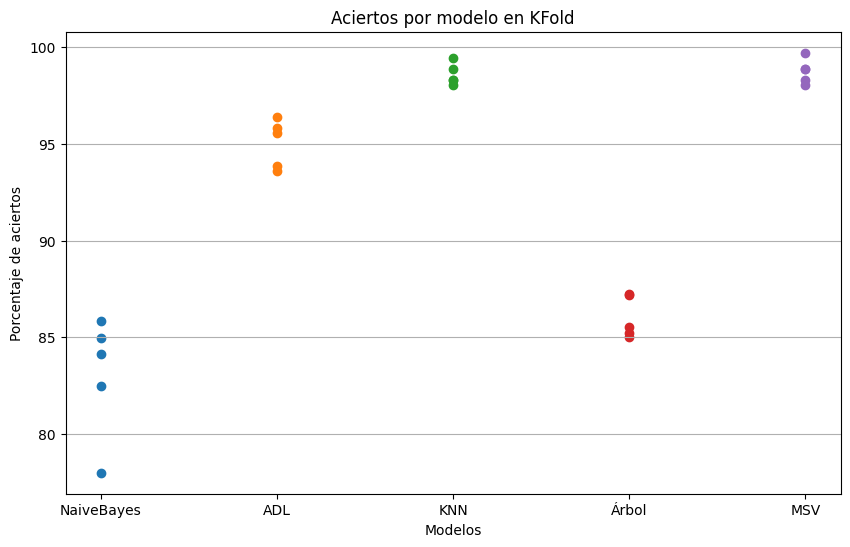

In [6]:
nombres = ['Naive Bayes', 
           'Análisis discriminante lineal (ADL)', 
           'K vecinos mas cercanos (KNN)', 
           'Árbol de decision', 
           'Máquina de soporte vectorial (MSV)']

modelos = [GaussianNB(), 
           LinearDiscriminantAnalysis(), 
           KNeighborsClassifier(), 
           DecisionTreeClassifier(random_state=2077), 
           SVC(random_state=2077)]

etiquetas = ['NaiveBayes', 'ADL', 'KNN', 'Árbol', 'MSV']

datos = []
for i in range(len(nombres)):
    resultados = evaluar_kfold(5, modelos[i])
    datos.append(resultados)

tabla_ex2 = resultados_a_df(nombres, datos)
display(tabla_ex2)

graficar(etiquetas, datos)

## Análisis de resultados — Ejercicio 2

En este ejercicio se comparó el desempeño del perceptrón multicapa con distintos clasificadores utilizando 5 particiones mediante KFold. Como referencia, el perceptrón multicapa obtuvo en el Ejercicio 1 una media de **94,77%** y una varianza de **0,0001385**.

El clasificador **Naive Bayes** obtuvo una media de **83,08%**, siendo el que presentó el menor rendimiento de todos los modelos evaluados. Además, tuvo una varianza de **0,0007679**, la más alta, indicando una mayor variabilidad entre las particiones.

El **Análisis Discriminante Lineal (ADL)** obtuvo una media de **95,05%**, ligeramente superior al perceptrón multicapa. Su varianza fue de **0,0001215**, menor que la del MLP, por lo que presentó resultados ligeramente más estables.

El algoritmo de **K vecinos más cercanos (KNN)** obtuvo una media de **98,61%**, superando ampliamente al perceptrón multicapa. Además, presentó una varianza muy baja de **0,0000248**, indicando una gran estabilidad entre las distintas particiones.

El **Árbol de Decisión** obtuvo una media de **86,09%**, inferior a la del perceptrón multicapa, aunque presentó una varianza de **0,0001087**, ligeramente menor que la del MLP.

Finalmente, la **Máquina de Soporte Vectorial (MSV)** obtuvo la mayor media de aciertos, con **98,78%**, superando ligeramente a KNN. Su varianza fue de **0,0000329**, por lo que también presentó resultados muy estables.

En conclusión, los mejores resultados fueron obtenidos por **MSV y KNN**, ambos con una precisión cercana al 99% y una baja variabilidad. El **ADL** tuvo un rendimiento similar al perceptrón multicapa, mientras que **Naive Bayes y el Árbol de Decisión** obtuvieron resultados considerablemente inferiores. En este conjunto de datos y con la configuración utilizada, los resultados indican un mejor desempeño de KNN y MSV frente al perceptrón multicapa.

## Ejercicio 3

Utilizando las funciones provistas por Scikit-learn, implemente los métodos de ensambles de clasificadores **Bagging** y **AdaBoost**. Compare el desempeño de estos modelos empleando 5 particiones con el conjunto de datos **Wine**.

,Particiones,Mínimo (%),Máximo (%),Media (%),Varianza
Modelo,,,,,
Bagging,5,94.44,97.22,96.63,0.000120
AdaBoost,5,88.57,100.00,95.48,0.001501


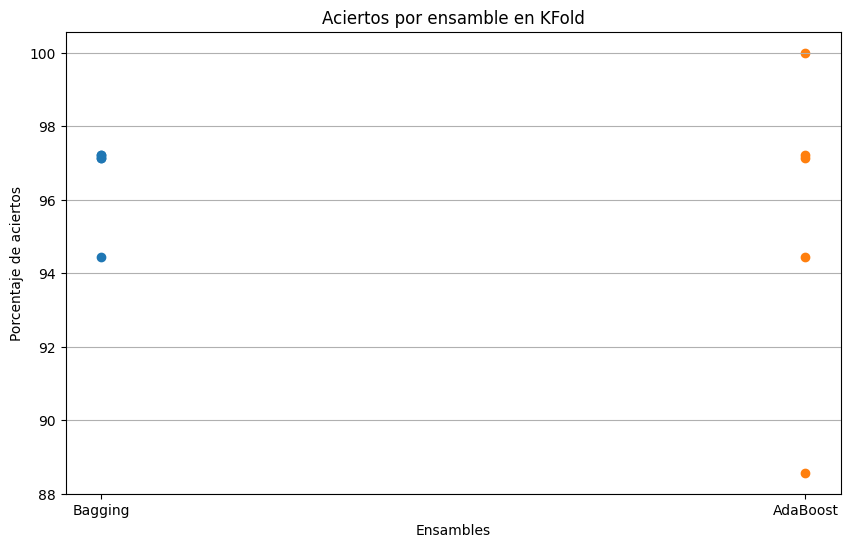

In [7]:
nombres = ['Bagging', 'AdaBoost']

titulo = 'Aciertos por ensamble en KFold'

xlabel = 'Ensambles'

modelos = [BaggingClassifier(random_state=2077), AdaBoostClassifier(random_state=2077)]

wine = load_wine()
X = wine.data
y = wine.target

datos = []
for i in range(len(nombres)):
    resultados = evaluar_kfold(5, modelos[i])
    datos.append(resultados)

tabla_ex3 = resultados_a_df(nombres, datos)
display(tabla_ex3)

graficar(nombres, datos, titulo, xlabel)

## Análisis de resultados — Ejercicio 3

En este ejercicio se comparó el desempeño de los métodos de ensamble Bagging y AdaBoost utilizando el conjunto de datos Wine y 5 particiones mediante KFold.

El modelo **Bagging** obtuvo porcentajes de aciertos entre **94,44% y 97,22%**, con una media de **96,63%** y una varianza de **0,0001201**. Los resultados fueron bastante similares entre las distintas particiones, lo que indica una buena estabilidad.

Por otro lado, **AdaBoost** obtuvo resultados entre **88,57% y 100%**, alcanzando una media de **95,48%** y una varianza de **0,0015006**. Si bien obtuvo el máximo porcentaje de aciertos en una de las particiones, presentó una variabilidad considerablemente mayor entre los distintos conjuntos de prueba.

Al comparar ambos métodos, **Bagging obtuvo una mayor media de aciertos y una varianza considerablemente menor que AdaBoost**. Por lo tanto, para este conjunto de datos y con la configuración utilizada, Bagging presentó un mejor desempeño promedio y resultados más estables.

En conclusión, **Bagging fue el método de ensamble que obtuvo mejores resultados en esta evaluación**, tanto por su mayor precisión promedio como por su menor variabilidad entre las particiones.

## Conclusión

A partir de los resultados obtenidos, se puede observar que el desempeño de los modelos depende tanto del algoritmo utilizado como del conjunto de datos y del método de evaluación. En el primer ejercicio, el perceptrón multicapa obtuvo resultados cercanos al 95% de aciertos, mostrando un desempeño estable con KFold. En el segundo ejercicio, los mejores resultados fueron obtenidos por KNN y la máquina de soporte vectorial, superando al perceptrón multicapa. Finalmente, en el tercer ejercicio, Bagging obtuvo un mejor desempeño promedio y una menor variabilidad que AdaBoost sobre el conjunto de datos Wine.

En general, los experimentos muestran la importancia de comparar distintos modelos y utilizar métodos de validación como KFold para obtener una evaluación más representativa de su desempeño.